In [ ]:
from typing import Tuple
import time
import random
import zipfile
from pathlib import Path

from PIL import Image
from tqdm import tqdm
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary

import torch
from torch import nn

from torchvision import datasets, transforms

In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 2
LR = 5e-5
TRAINING_STEPS = 10000
EPOCHS = 50
GAMMA = 0.7

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
image_path = Path("data/")

start_time = time.time()
with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    print("Unzipping clinical images...")
    zip_ref.extractall(image_path)
print(f"Unzipping completed in {time.time() - start_time:.2f} seconds.")

Unzipping clinical images...
Unzipping completed in 10.83 seconds.


In [8]:
train_dir = image_path / "train"
test_dir = image_path / "test"

Random image path: data/train/diabetes/04031.bmp
Image class: diabetes
Image height: 384
Image width: 384


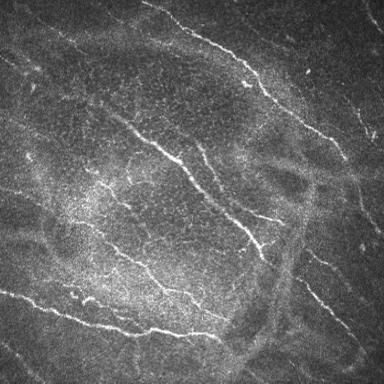

In [9]:
image_path_list = list(image_path.glob("*/*/*.bmp"))

random_image_path = random.choice(image_path_list)

image_class = random_image_path.parent.stem

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

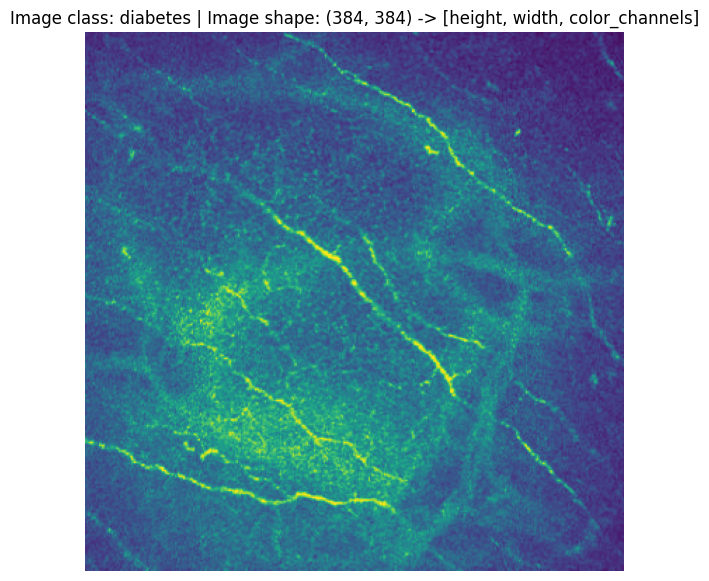

In [10]:
img_as_array = np.asarray(img)

plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

In [11]:
transform = transforms.Compose([
    # transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),
    # transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print(transform)

Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [12]:
train_dataset= datasets.ImageFolder(root=train_dir, transform=transform, target_transform=None)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

print(f"Train data:\n{train_dataset}\nTest data:\n{test_dataset}")

Train data:
Dataset ImageFolder
    Number of datapoints: 10888
    Root location: data/train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 4313
    Root location: data/test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [13]:
class_names = train_dataset.classes
class_dict = train_dataset.class_to_idx
class_names, class_dict

(['control', 'diabetes'], {'control': 0, 'diabetes': 1})

In [14]:
for i, (img, label) in enumerate(train_dataset):
    print(i, img.size(), label)

    if i == 3:
        break

0 torch.Size([3, 384, 384]) 0
1 torch.Size([3, 384, 384]) 0
2 torch.Size([3, 384, 384]) 0
3 torch.Size([3, 384, 384]) 0


In [15]:
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [16]:
@dataclass
class ModelConfig:
    hidden_size: int
    n_heads: int
    n_layers: int
    mlp_size: int
    attn_dropout: float
    mlp_dropout: float
    qkv_bias: bool

    n_classes: int
    channels: int
    patch_size: int
    img_size: int
    height: int
    width: int

In [17]:
class PatchEmbedding(nn.Module):

    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.patcher = nn.Conv2d(
            in_channels= model_config.channels,
            out_channels = model_config.hidden_size,
            kernel_size=model_config.patch_size,
            stride=model_config.patch_size,
            padding=0
        )

        self.flatten = nn.Flatten(
            start_dim=2, # only flatten the feature map dimensions into a single vector
            end_dim=3
        )

        self.patch_size = model_config.patch_size

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # (batch_size, channel, height, width)
        image_resolution = x.shape[-1]

        assert image_resolution % self.patch_size == 0, f"Input image size must be divisble by patch size."

        # (batch_size, channel, height, width) -> (batch_size, hidden_size, height / patch_size, width / patch_size)
        # hidden_size = patch_size * patch_size * channels
        x_patched = self.patcher(x)

        # (batch_size, hidden_size, height / patch_size, width / patch_size) -> (batch_size, hidden_size, height / patch_size * width / patch_size)
        # patches_num = height / patch_size * width / patch_size
        x_flattened = self.flatten(x_patched)

        # also called seq length
        # (batch_size, hidden_size, patches_num x patches_num) -> (batch_size, patches_num x patches_num, hidden_size),
        x_permuted = x_flattened.permute(0, 2, 1)

        return x_permuted

In [18]:
class MultiHeadAttention(nn.Module):

    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.ln = nn.LayerNorm(model_config.hidden_size)

        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=model_config.hidden_size,
            num_heads=model_config.n_heads,
            dropout=model_config.attn_dropout,
            batch_first=True
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ln(x)
        attn_output, _ = self.multihead_attn(query=x, key=x, value=x, need_weights=False)
        return attn_output

In [19]:
class MLP(nn.Module):
    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.ln = nn.LayerNorm(model_config.hidden_size)

        self.mlp = nn.Sequential(
            nn.Linear(in_features = model_config.hidden_size, out_features = model_config.mlp_size),
            nn.GELU(),
            nn.Dropout(model_config.mlp_dropout),
            nn.Linear(in_features = model_config.mlp_size, out_features = model_config.hidden_size),
            nn.Dropout(model_config.mlp_dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ln(x)
        x = self.mlp(x)
        return x


In [20]:
class Encoder(nn.Module):
    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        self.msa = MultiHeadAttention(model_config)
        self.mlp =  MLP(model_config)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x =  self.msa(x) + x
        x = self.mlp(x) + x
        return x

In [21]:
class ViT(nn.Module):
    def __init__(self, model_config: ModelConfig) -> None:
        super().__init__()

        assert model_config.img_size % model_config.patch_size == 0, f"Image size must be divisible by patch size."

        self.num_patches = (model_config.img_size * model_config.img_size) // model_config.patch_size**2

        self.class_embedding = nn.Parameter(data=torch.randn(1, 1, model_config.hidden_size), requires_grad=True)

        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, model_config.hidden_size), requires_grad=True)

        self.patch_embedding = PatchEmbedding(model_config)

        self.transformer_encoder = nn.Sequential(
            *[
                Encoder(model_config)
                for _ in range(model_config.n_layers)
            ]
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(model_config.hidden_size),
            nn.Linear(model_config.hidden_size, model_config.n_classes)
        )

    def forward(self, x):

        batch_size = x.shape[0]

        # expand to match the batch size, "-1" infer dimension
        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x

        x = self.transformer_encoder(x)

        x = self.classifier(x[:, 0])

        return x

In [22]:
model_variants = {
    'tiny': { 'n_layers': 3, 'hidden_size': 192, 'mlp_size': 768, 'n_heads': 3, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'small': { 'n_layers': 12, 'hidden_size': 384, 'mlp_size': 3072, 'n_heads': 6, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'base': { 'n_layers': 12, 'hidden_size': 768, 'mlp_size': 3072, 'n_heads': 12, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'large': { 'n_layers': 24, 'hidden_size': 1024, 'mlp_size': 4096, 'n_heads': 16, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False },
    'huge': { 'n_layers': 32, 'hidden_size': 1280, 'mlp_size': 5120, 'n_heads': 16, 'attn_dropout' : 0.0, 'mlp_dropout' : 0.1, 'qkv_bias' : False }
}

In [23]:
dataset_params = { "n_classes": 2, "channels": 3, "patch_size": 16, "img_size": 384, "height": 384, "width": 384}

In [24]:
model_config = model_variants.get("small")

In [25]:
config = ModelConfig(
            n_layers = model_config['n_layers'],
            hidden_size = model_config['hidden_size'],
            mlp_size = model_config['mlp_size'],
            n_heads = model_config['n_heads'],
            attn_dropout = model_config['attn_dropout'],
            mlp_dropout = model_config['mlp_dropout'],
            qkv_bias = model_config['qkv_bias'],
            **dataset_params
        )

In [26]:
import gc
# del model
gc.collect()
torch.cuda.empty_cache()

In [27]:
model = ViT(config)

In [28]:
summary(model, input_size=[BATCH_SIZE, 3, 384, 384])

Layer (type:depth-idx)                        Output Shape              Param #
ViT                                           [32, 2]                   221,952
├─PatchEmbedding: 1-1                         [32, 576, 384]            --
│    └─Conv2d: 2-1                            [32, 384, 24, 24]         295,296
│    └─Flatten: 2-2                           [32, 384, 576]            --
├─Sequential: 1-2                             [32, 577, 384]            --
│    └─Encoder: 2-3                           [32, 577, 384]            --
│    │    └─MultiHeadAttention: 3-1           [32, 577, 384]            592,128
│    │    └─MLP: 3-2                          [32, 577, 384]            2,363,520
│    └─Encoder: 2-4                           [32, 577, 384]            --
│    │    └─MultiHeadAttention: 3-3           [32, 577, 384]            592,128
│    │    └─MLP: 3-4                          [32, 577, 384]            2,363,520
│    └─Encoder: 2-5                           [32, 577, 384] 

In [30]:
model.to(device)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [31]:
def train_step(
    model: torch.nn.Module,
    dataloader: DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:

    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [32]:
def test_step(
    model: torch.nn.Module,
    dataloader: DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device
) -> Tuple[float, float]:

    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):

            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc

In [33]:
def train(
    model: torch.nn.Module,
    train_dataloader: DataLoader,
    test_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    epochs: int,
    device: torch.device
) -> None:

    model.to(device)

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):

        train_loss, train_acc = train_step(
                                    model=model,
                                    dataloader=train_dataloader,
                                    loss_fn=loss_fn,
                                    optimizer=optimizer,
                                    device=device
                                )

        test_loss, test_acc = test_step(
                                    model=model,
                                    dataloader=test_dataloader,
                                    loss_fn=loss_fn,
                                    device=device
                                )

        print(
          f" Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [ ]:
results = train(model, train_dataloader, test_dataloader, optimizer, loss_fn, EPOCHS, device)

In [35]:
def plot_loss_curves(results):

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

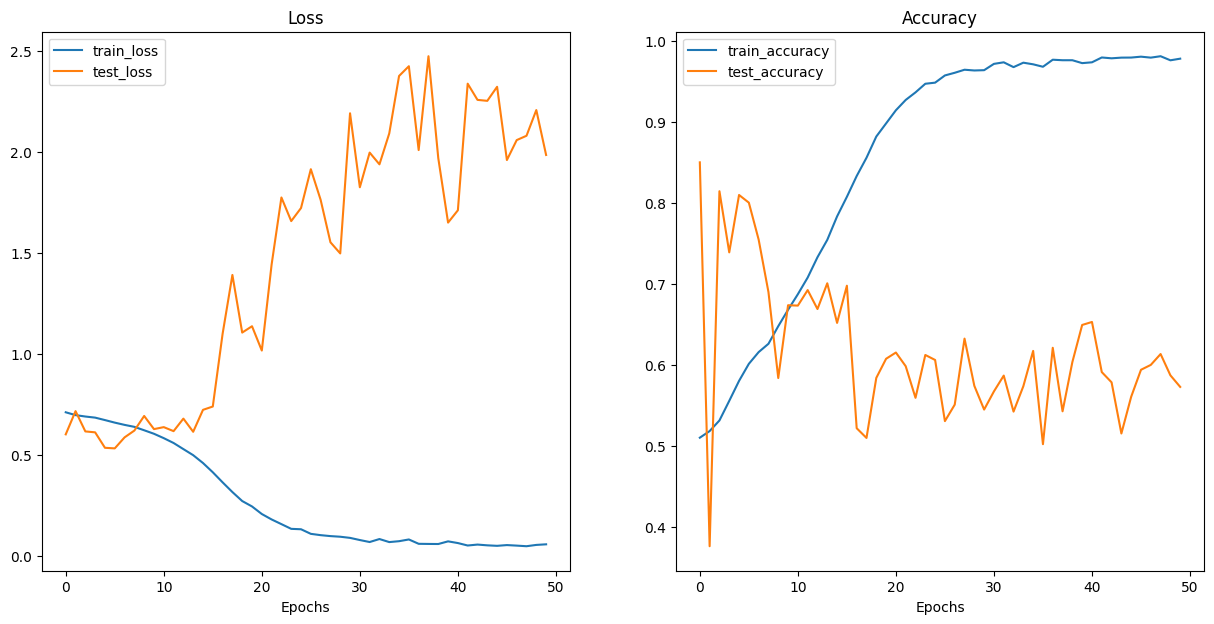

In [36]:
plot_loss_curves(results)

In [37]:
torch.save(obj=model.state_dict(), f="vit_v1.pth")